In [20]:
pip install requests wikipedia-api wptools pygbif pandas scikit-learn shap rasterio tqdm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd

df = pd.read_csv("threatened-species.csv")

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'threatened-species.csv'

In [ ]:
#Filter by animals 

tiere_df = df[df['kingdom_name'] == 'ANIMALIA']
print(tiere_df.head())

      taxonid kingdom_name phylum_name class_name    order_name  \
6866    39250     ANIMALIA    CHORDATA   MAMMALIA  ARTIODACTYLA   
6867    39255     ANIMALIA    CHORDATA   MAMMALIA  ARTIODACTYLA   
6868    39258     ANIMALIA    CHORDATA   REPTILIA      SQUAMATA   
6869    39260     ANIMALIA    CHORDATA   REPTILIA      SQUAMATA   
6870    39262     ANIMALIA    CHORDATA   AMPHIBIA       CAUDATA   

         family_name genus_name       scientific_name  \
6866         BOVIDAE       Ovis            Ovis dalli   
6867         BOVIDAE  Rupicapra   Rupicapra rupicapra   
6868  DIPLOGLOSSIDAE  Caribicus  Caribicus anelpistus   
6869  DIPLOGLOSSIDAE  Caribicus     Caribicus warreni   
6870  PLETHODONTIDAE    Eurycea      Eurycea rathbuni   

                       taxonomic_authority infra_rank infra_name population  \
6866                          Nelson, 1884        NaN        NaN        NaN   
6867                      (Linnaeus, 1758)        NaN        NaN        NaN   
6868  (Schwartz, 

In [ ]:
# Welche Tierklassen sind am häufigsten vertreten?
animal_classes = df[df['kingdom_name'] == 'ANIMALIA']['class_name'].value_counts()
print(animal_classes)

class_name
ACTINOPTERYGII    26078
INSECTA           12440
AVES              11195
REPTILIA           9929
AMPHIBIA           7790
GASTROPODA         5834
MALACOSTRACA       2786
MAMMALIA           2728
CHONDRICHTHYES     1275
ANTHOZOA            946
ARACHNIDA           769
CEPHALOPODA         754
BIVALVIA            639
HOLOTHUROIDEA       371
CLITELLATA          363
DIPLOPODA           250
MYXINI               80
PETROMYZONTI         32
COLLEMBOLA           28
DEMOSPONGIAE         22
HYDROZOA             15
SARCOPTERYGII        10
CHILOPODA            10
BRANCHIOPODA          5
SOLENOGASTRES         4
POLYPLACOPHORA        2
CALCAREA              2
MONOPLACOPHORA        1
ASTEROIDEA            1
HEXANAUPLIA           1
OSTRACODA             1
TURBELLARIA           1
Name: count, dtype: int64


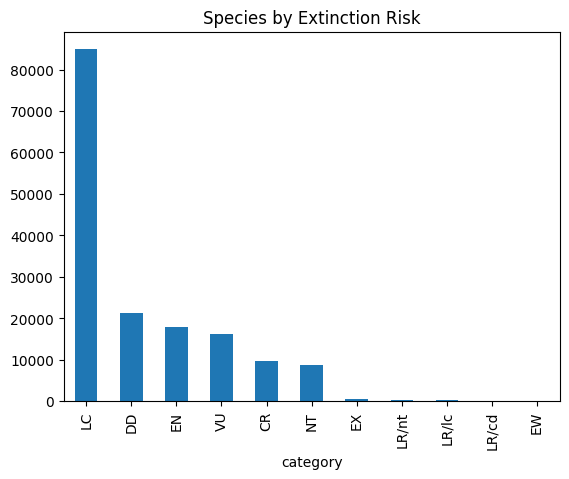

In [ ]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar")
plt.title("Species by Extinction Risk")
plt.show()

In [ ]:
pip install IUCN-API


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import requests
import pandas as pd
import time

TOKEN = "N9bEFzcD6a65sGnyMc9qJkghuwf3ySJKSR9b"
BASE  = "https://api.iucnredlist.org/api/v4"

HEADERS = {"Authorization": f"Token {TOKEN}"}

def get_all_animals():
    all_species = []
    page = 0
    
    while True:
        print(f"Fetching page {page}...")
        
        # v4 correct endpoint for species list
        response = requests.get(
            f"{BASE}/assessments",
            params={"page": page},
            headers=HEADERS
        )
        
        print(f"Status: {response.status_code}")
        
        if response.status_code == 401:
            print("Token rejected — check your token")
            break
        elif response.status_code == 404:
            print("Endpoint not found — trying alternative")
            break
        elif response.status_code != 200:
            print(f"Error {response.status_code}: {response.text[:200]}")
            break
        
        data = response.json()
        results = data.get('assessments', 
                  data.get('results', []))
        
        if not results:
            print("No more results — done!")
            break
        
        all_species.extend(results)
        print(f"Total so far: {len(all_species)}")
        page += 1
        time.sleep(2)
    
    return pd.DataFrame(all_species)

df = get_all_animals()
print(df.head())

Fetching page 0...
Status: 404
Endpoint not found — trying alternative
Empty DataFrame
Columns: []
Index: []


WIKIPEDIA 

In [ ]:
pip install wptools wikipedia requests pandas tqdm

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11756 sha256=19d9249daf948707b0b2f676739010777268467b65f3e75b19e98a545f40d0c7
  Stored in directory: /Users/tizgalajxhi/Library/Caches/pip/wheels/79/1d/c8/b64e19423cc5a2a339450ea5d145e7c8eb3d4aa2b150cde33b
Successfully built wikipedia

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import wptools
import re

def get_infobox(species_name):
    try:
        page = wptools.page(species_name, silent=True)
        page.get_parse()
        infobox = page.data.get('infobox', {}) or {}
        return infobox
    except Exception as e:
        return {}

# Test with one species first
infobox = get_infobox("Tiger")
print(infobox)
# Example output:
# {'mass': '90–310 kg', 'diet': 'Carnivore',
#  'habitat': 'Forest', 'status': 'EN'}

{'fossil_range': '{{fossil range|Early Pleistocene | Present}}', 'image': '{{CSS image crop    |Image |=| Bengal tiger (Panthera tigris tigris) female 3 crop.jpg    |bSize |=| 350    |cWidth |=| 300    |cHeight |=| 170    |oTop |=| 40    |oLeft |=| 30    |Location |=| center}}', 'image_caption': 'Female [[Bengal tiger]] in [[Kanha Tiger Reserve]], India', 'image_upright': '1.2', 'status': 'EN', 'status_system': 'IUCN3.1', 'status2': 'CITES_A1', 'status2_system': 'CITES', 'taxon': 'Panthera tigris', 'authority': '([[Carl Linnaeus|Linnaeus]], 1758)', 'subdivision_ranks': 'Subspecies', 'subdivision': "* ''[[Panthera tigris tigris|P. t. tigris]]''\n* ''[[Sunda Island tiger|P. t. sondaica]]''\n* {{extinct}} ''[[Panthera tigris acutidens|P. t. acutidens]]''\n* {{extinct}} ''[[Panthera tigris soloensis|P. t. soloensis]]''\n* {{extinct}} ''[[Panthera tigris trinilensis|P. t. trinilensis]]''", 'range_map': 'Tiger distribution.png', 'range_map_caption': 'Tiger distribution as of 2022', 'range_ma

In [ ]:
import re

def parse_mass(text):
    """Converts '90-310 kg' -> 200.0 (average)"""
    if not text:
        return None
    # Remove references like [1], [2]
    text = re.sub(r'\[.*?\]', '', str(text))
    nums = re.findall(r'[\d.]+', text)
    if nums:
        values = [float(n) for n in nums]
        return sum(values) / len(values)
    return None

def parse_habitat(text):
    """Converts free text habitat to a category"""
    if not text:
        return 'unknown'
    text = str(text).lower()
    habitats = {
        'forest':    ['forest', 'woodland', 'jungle', 'rainforest'],
        'ocean':     ['ocean', 'marine', 'sea', 'coastal'],
        'grassland': ['grassland', 'savanna', 'prairie', 'steppe'],
        'wetland':   ['wetland', 'swamp', 'marsh', 'river', 'lake'],
        'desert':    ['desert', 'arid', 'dry'],
        'tundra':    ['tundra', 'arctic', 'alpine', 'mountain'],
    }
    for category, keywords in habitats.items():
        if any(kw in text for kw in keywords):
            return category
    return 'unknown'

def parse_diet(text):
    """Converts diet text to carnivore/herbivore/omnivore"""
    if not text:
        return 'unknown'
    text = str(text).lower()
    if any(w in text for w in ['carnivore', 'meat', 'fish', 'insect']):
        return 'carnivore'
    elif any(w in text for w in ['herbivore', 'plant', 'grass', 'leaves']):
        return 'herbivore'
    elif any(w in text for w in ['omnivore', 'both', 'varied']):
        return 'omnivore'
    return 'unknown'

def parse_lifespan(text):
    """Converts '20-25 years' -> 22.5"""
    return parse_mass(text)  # same logic, extracts average number

In [ ]:
import wikipedia

def get_threat_features(species_name):
    """
    Reads the Wikipedia article body and counts
    how many threat types are mentioned
    """
    try:
        page = wikipedia.page(species_name, auto_suggest=False)
        text = page.content.lower()

        threats = {
            'hunting':        ['hunting', 'poaching', 'overhunting'],
            'habitat_loss':   ['habitat loss', 'deforestation', 
                               'land clearing'],
            'climate_change': ['climate change', 'global warming',
                               'temperature rise'],
            'invasive':       ['invasive species', 'introduced species',
                               'predation by'],
            'disease':        ['disease', 'infection', 'epidemic'],
            'pollution':      ['pollution', 'pesticide', 'toxic'],
        }

        threat_flags = {}
        for threat_name, keywords in threats.items():
            # 1 if mentioned, 0 if not
            threat_flags[threat_name] = int(
                any(kw in text for kw in keywords)
            )

        # Total number of threats mentioned
        threat_flags['total_threats'] = sum(threat_flags.values())
        return threat_flags

    except Exception:
        return {
            'hunting': 0, 'habitat_loss': 0,
            'climate_change': 0, 'invasive': 0,
            'disease': 0, 'pollution': 0,
            'total_threats': 0
        }

# Test
print(get_threat_features("Tiger"))
# {'hunting': 1, 'habitat_loss': 1, 'climate_change': 1,
#  'invasive': 0, 'disease': 0, 'pollution': 1, 'total_threats': 4}

{'hunting': 1, 'habitat_loss': 1, 'climate_change': 0, 'invasive': 0, 'disease': 1, 'pollution': 0, 'total_threats': 3}


In [ ]:
def get_all_wikipedia_features(species_name):
    """
    Master function — call this once per species
    returns a clean dict of all features
    """
    print(f"Fetching: {species_name}")

    # Get infobox
    infobox = get_infobox(species_name)

    # Get threat features from article text
    threats = get_threat_features(species_name)

    # Combine into one clean row
    features = {
        'species':      species_name,
        'mass_kg':      parse_mass(infobox.get('mass')),
        'lifespan_yr':  parse_lifespan(infobox.get('lifespan')),
        'habitat':      parse_habitat(infobox.get('habitat', '')),
        'diet':         parse_diet(infobox.get('diet', '')),
        'found_on_wiki': True
    }

    # Add all threat columns
    features.update(threats)
    return features

# Test with one species
result = get_all_wikipedia_features("Tiger")
print(result)

Fetching: Tiger
{'species': 'Tiger', 'mass_kg': None, 'lifespan_yr': None, 'habitat': 'unknown', 'diet': 'unknown', 'found_on_wiki': True, 'hunting': 1, 'habitat_loss': 1, 'climate_change': 0, 'invasive': 0, 'disease': 1, 'pollution': 0, 'total_threats': 3}
